<a href="https://colab.research.google.com/github/sbednarz/ModelowanieProcesowBiotechnologicznych2026/blob/main/kinetyka_bioproces%C3%B3w/modele_wzrostu_podstawy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📚 Przykładowe funkcje szybkości wzrostu mikroorganizmów (niesegregowane, niestrukturalne)

### 1. Stała szybkość wzrostu

Najprostszy model teoretyczny (idealna faza logarytmicznego wzrostu).

$$
\mu = \mu_0
$$

### 2. Wzrost logistyczny

Ograniczony.

$$
\mu = \mu_{max}\left(1 - \frac{X}{X_{max}}\right)
$$


### 3. Model Monoda

Najczęściej stosowany model ograniczenia substratem.

$$
\mu = \mu_{max}\frac{S}{K_S + S}
$$



### 4. Model Tessiera

Alternatywa dla Monoda.

$$
\mu = \mu_{max}(1 - e^{-S/K_S})
$$



### 5. Model Mosera

Uogólnienie Monoda.

$$
\mu = \mu_{max}\frac{S^n}{K_S + S^n}
$$



### 6. Model Contoisa

Model przy dużych stężeniach biomasy.

$$
\mu = \mu_{max}\frac{S}{K_S X + S}
$$



### 7. Model Andrews / Haldane

Inhibicja substratem.

$$
\mu = \mu_{max}\frac{S}{K_S + S + S^2/K_I}
$$


### 8. Inhibicja produktem

$$
\mu = \mu_{max}\frac{S}{K_S + S}\frac{1}{1 + P/K_P}
$$



### 9. Ograniczenie tlenowe

$$
\mu = \mu_{max}\frac{S}{K_S + S}\frac{O}{K_O + O}
$$





### 1. Model Monoda

Podstawowy model wzrostu ograniczanego stężeniem substratu.

$$
\mu = \mu_{max}\frac{S}{K_S + S}
$$

---

### 2. Model Monoda z utrzymaniem komórek (maintenance, Pirt)

Wzrost nadal opisuje Monod, ale substrat jest zużywany nie tylko na wzrost, lecz także na potrzeby podtrzymania metabolizmu.

$$
\mu = \mu_{max}\frac{S}{K_S + S}
$$

$$
\frac{dX}{dt} = \mu X
$$

$$
\frac{dS}{dt} = -\frac{1}{Y_{X/S}}\mu X - m_S X
$$

gdzie:
- $Y_{X/S}$ – wydajność biomasy względem substratu
- $m_S$ – współczynnik maintenance

---

### 3. Model Luedekinga–Pireta

Opis produkcji metabolitu jako sumy części związanej ze wzrostem i niezwiązanej ze wzrostem.

$$
\frac{dP}{dt} = \alpha \mu X + \beta X
$$

gdzie:
- $\alpha$ – składnik związany ze wzrostem
- $\beta$ – składnik niezwiązany ze wzrostem

Interpretacja:
- jeśli $\beta = 0$, produkt jest związany tylko ze wzrostem
- jeśli $\alpha = 0$, produkt jest niezwiązany ze wzrostem
- jeśli oba są różne od zera, model jest mieszany

---

### 4. Model Monoda z ograniczeniem tlenowym

Wzrost zależy jednocześnie od substratu i tlenu.

$$
\mu = \mu_{max}\frac{S}{K_S + S}\frac{O}{K_O + O}
$$

gdzie:
- $O$ – stężenie rozpuszczonego tlenu
- $K_O$ – stała nasycenia dla tlenu

---

### 5. Model Monoda z ograniczeniem tlenowym i bilansem biomasy

$$
\mu = \mu_{max}\frac{S}{K_S + S}\frac{O}{K_O + O}
$$

$$
\frac{dX}{dt} = \mu X
$$

---

### 6. Model Monoda z ograniczeniem tlenowym i bilansem substratu

$$
\mu = \mu_{max}\frac{S}{K_S + S}\frac{O}{K_O + O}
$$

$$
\frac{dS}{dt} = -\frac{1}{Y_{X/S}}\mu X
$$

---

### 7. Model Monoda z ograniczeniem tlenowym i bilansem tlenu

$$
\mu = \mu_{max}\frac{S}{K_S + S}\frac{O}{K_O + O}
$$

$$
\frac{dO}{dt} = k_La(O^* - O) - q_O X
$$

gdzie:
- $k_La$ – objętościowy współczynnik przenikania tlenu
- $O^*$ – stężenie tlenu w stanie nasycenia
- $q_O$ – szybkość zużycia tlenu przez biomasę

---

### 8. Pełny prosty model: Monod + maintenance + tlen + produkt

$$
\mu = \mu_{max}\frac{S}{K_S + S}\frac{O}{K_O + O}
$$

$$
\frac{dX}{dt} = \mu X
$$

$$
\frac{dS}{dt} = -\frac{1}{Y_{X/S}}\mu X - m_S X
$$

$$
\frac{dP}{dt} = \alpha \mu X + \beta X
$$

$$
\frac{dO}{dt} = k_La(O^* - O) - q_O X
$$

### 📊 Model 1. Stała szybkość wzrostu

Najprostszy model teoretyczny (idealna faza logarytmicznego wzrostu).

$$
\mu = \mu_0
$$

$$
\frac{dX}{dt} = \mu X
$$

Parametry:

$\mu$ - specyficzna szybkość wzrostu biomasy

$X$ - stężenie biomasy

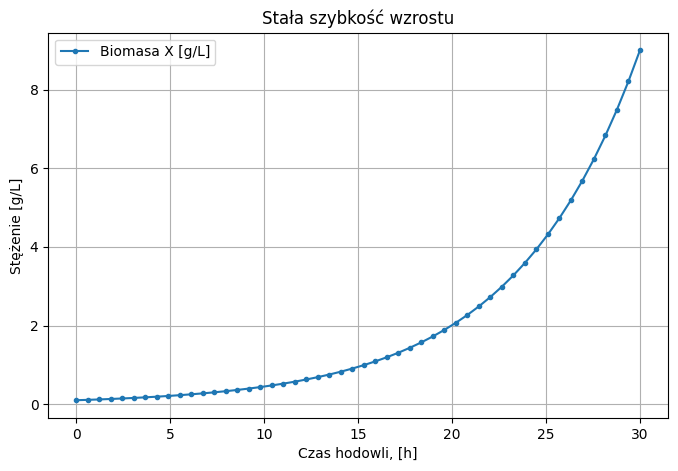

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# parametry
mu0 = 0.15 # 1/h

# warunki początkowe
X0 = 0.1 # g/L
y0 = [X0]

# przedział czasu, początek - koniec
t_span = (0, 30)  # h
# przedział podzielony na N punktów obliczeniowych
N = 50
t_eval = np.linspace(t_span[0], t_span[1], N)


def model(t, y):
    X = y
    mu = mu0
    dXdt = mu * X
    return [dXdt]

# rozwiązanie
sol = solve_ivp(model, t_span, y0, t_eval=t_eval)

# wyniki (wektory)
t = sol.t # punkty czasu w których przeprowadzono obliczenia (czyli t_eval)
X = sol.y[0] # obliczone stężenie biomasy

# wykres
plt.figure(figsize=(8, 5))
plt.plot(t, X, '.-', label="Biomasa X [g/L]")
plt.xlabel("Czas hodowli, [h]")
plt.ylabel("Stężenie [g/L]")
plt.title("Stała szybkość wzrostu")
plt.legend()
plt.grid(True)
plt.show()

### 🔍 Dyskusja i zadania
* Wyzaczanie stężenia bimasy
* Wpływ `X0` i `mu0` na przebieg hodowli
* Autokataliza


### 📊 Co oznacza μ (mu) w modelach wzrostu mikroorganizmów

Parametr $\mu$ oznacza specyficzną szybkość wzrostu biomasy.

Jest to tempo wzrostu populacji mikroorganizmów w przeliczeniu na jednostkę biomasy (czyli znormalizowane).

$$
\mu = \frac{1}{X}\frac{dX}{dt} = \frac{r_X}{X}
$$

gdzie:

- $X$ — stężenie biomasy (np. g/L)
- $\frac{dX}{dt} = r_X$ — szybkość zmiany biomasy

Wymiar $\mu$:

$$
\mu \; [h^{-1}]
$$

czyli wzrost względny na jednostkę czasu.


W wielu modelach:

$$
\mu \le \mu_{max}
$$

gdzie $\mu_{max}$ to maksymalna specyficzna szybkość wzrostu.

Związek z czasem podwojenia biomasy

$$
t_d = \frac{\ln 2}{\mu}
$$

gdzie $t_d$ oznacza **czas podwojenia biomasy**.